In [1]:
import os
import sys
sys.path.append('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/W51CA3_Fitting/hiimodel')

from HII_model import HIIregion
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np


import numpy as np
import warnings
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube, Projection
from astropy.modeling import models, fitting
from astropy.convolution import convolve_models
from astropy import units as u
from astropy.io import fits
import radio_beam
from radio_beam import Beam
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [ ]:
#Accessing Cube Data
def fit_2dgaussian(directory, maser_table, freq, amplitude, x, y, x_stddev, y_stddev, 
    theta=np.pi/3, size=13, channel=0, cube=True, format='fits', table=True, source_name='None',
    fixed_xstddev=False, fixed_ystddev=False, fixed_theta=False):

    """
    Fit a 2D Gaussian to a cutout of a spectral cube or image.

    """

    if cube:
        
        cube = SpectralCube.read(directory, format=format)

        if channel is None:
            pass
        else:
            cube = cube[channel,:,:]

        cube_cutout = cube[y - size:y + size, x - size:x + size]
        yy, xx = cube_cutout.spatial_coordinate_map

        cord = cube.world[y,x]

        x_guess, y_guess = cord[1], cord[0]

    else:
        
        hdul = fits.open(directory)

        hdu = hdul[0]

        data_cube = hdul[0].data

        if data_cube.ndim == 4:
            data = data_cube[0, 0, :, :] * u.Jy/u.beam

        else:
            data = hdu.data * u.Jy/u.beam

        header = hdu.header

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ww = WCS(header)

        data_cutout = data[y - size:y + size, x - size:x + size]
        ypixel_grid, xpixel_grid = np.mgrid[y - size:y + size, x - size:x + size]
        
        # xx, yy = ww.pixel_to_world_values(xpixel_grid, ypixel_grid)

        # xx = (xx * u.deg)
        # yy = (yy * u.deg)

        # x_guess, y_guess = xx[size, size], ypixel_grid[size, size]

    p_init_gauss2D = models.Gaussian2D(x_mean=x, y_mean=y, amplitude=amplitude * (u.Jy/u.beam),
                                    x_stddev=(x_stddev), y_stddev=(y_stddev), theta=(theta)*u.rad)

    if fixed_xstddev:
        p_init_gauss2D.x_stddev.fixed = True

    if fixed_ystddev:
        p_init_gauss2D.y_stddev.fixed = True

    if fixed_theta:
        p_init_gauss2D.theta.fixed = True

    fit_p = fitting.LevMarLSQFitter()
    data_cutout[np.isnan(data_cutout)] = 0.

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p_gauss2D = fit_p(p_init_gauss2D, xpixel_grid, ypixel_grid, data_cutout)

  
    cov = np.diag(fit_p.fit_info['param_cov'])
    errors = np.sqrt(cov)

    amplitude_error=np.format_float_scientific(errors[0],precision=9)
    x_mean_error=np.format_float_scientific(errors[1],precision=9)
    y_mean_error=np.format_float_scientific(errors[2],precision=9)
    x_stddev_error=np.format_float_scientific(errors[3],precision=9)
    y_stddev_error=np.format_float_scientific(errors[4],precision=9)
    theta_error=np.format_float_scientific(errors[5],precision=9)

    amplitude = np.format_float_scientific(p_gauss2D.amplitude[0],precision=9)
    x_mean = np.format_float_scientific(p_gauss2D.x_mean[0],precision=9)
    y_mean = np.format_float_scientific(p_gauss2D.y_mean[0],precision=9)
    x_stddev = np.format_float_scientific(p_gauss2D.x_stddev[0],precision=9)
    y_stddev = np.format_float_scientific(p_gauss2D.y_stddev[0],precision=9)
    theta = np.format_float_scientific(p_gauss2D.theta[0],precision=9)

                
    plt.figure(figsize=(20, 6))
    plt.suptitle(f"Source-{source_name} freq-{freq}", fontsize=18)

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(data_cutout.value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Model")
    plt.imshow(p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Residual")
    plt.imshow(data_cutout.value - p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar(label='S (Jy)')

    plt.show()

    print("Parameter" + ' ' + 'Error' +"\n")
    print("Amplitude" +"\n")
    print(amplitude + ' ' + amplitude_error +"\n")

    print("x_mean"  +"\n")
    print(x_mean + ' ' + x_mean_error +"\n")

    print("y_mean" +"\n")
    print(y_mean + ' ' + y_mean_error +"\n")

    print("x_stddev" +"\n")
    print(x_stddev + ' ' + x_stddev_error +"\n")

    print("y_stddev" +"\n")
    print(y_stddev + ' ' + y_stddev_error +"\n")

    print("theta" +"\n")
    print(theta + ' ' + theta_error +"\n")

    # print('\n\nSkyCoord Conversion \n----------------- \n')
    # print("Parameter" + ' ' + 'Error' +"\n")

    skycoord = pixel_to_skycoord(float(x_mean), float(y_mean), ww)
    skycoord_err = SkyCoord(ra=x_mean_error, dec=y_mean_error, unit=(u.deg, u.deg), frame=ww.wcs.radesys.lower())

    # error propagation? # Not sure if this is correct
    skycoord_error = pixel_to_skycoord(float(x_mean_error), float(y_mean_error), ww)


    ra_hms_str = skycoord.ra.to_string(unit=u.hour, sep=':', precision=4)
    dec_dms_str = skycoord.dec.to_string(unit=u.deg, sep=':', precision=4)


    print(skycoord_error)

    if table:
        new_row = pd.DataFrame({'source': [source_name] , 
            'freq': [freq], 'x_pix': [x], 'y_pix': [y], 'amplitude': [amplitude], 
            'amplitude_error': [amplitude_error], 'x_mean': [x_mean], 'x_mean_error': [x_mean_error], 
            'y_mean': [y_mean], 'y_mean_error': [y_mean_error], 
            'x_mean_sky': [skycoord.ra.deg], 'x_mean_sky_error': [skycoord_error.ra.deg],
            'y_mean_sky': [skycoord.dec.deg], 'y_mean_sky_error': [skycoord_error.dec.deg],
            'ra_hms': [ra_hms_str], 'dec_dms': [dec_dms_str],
            'SkyCoord' : [skycoord],
            'frame': [skycoord.frame.name], 
            'header': [ww]})
        maser_table = pd.concat([maser_table, new_row], ignore_index=True)

        return maser_table

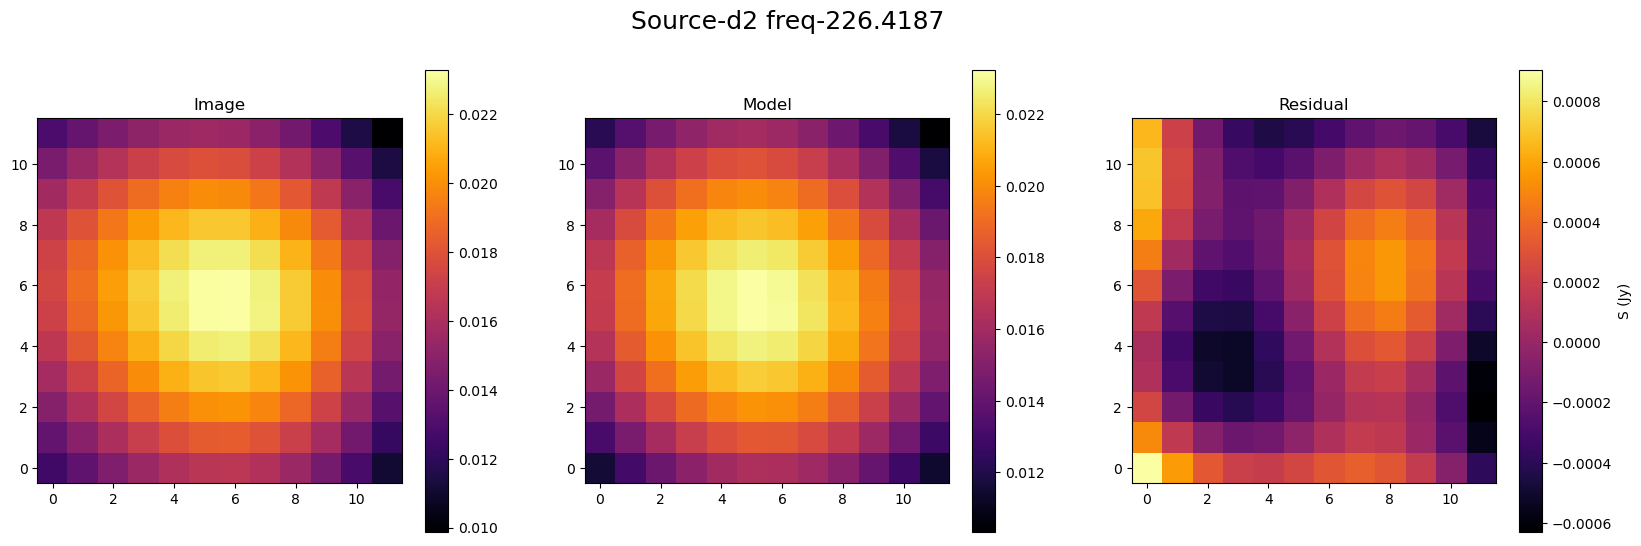

Parameter Error

Amplitude

2.3301455e-02 2.878165664e-04

x_mean

4.653145318e+03 1.026774425e-01

y_mean

3.310433439e+03 9.774275679e-02

x_stddev

6.326073193e+00 1.709450035e-01

y_stddev

6.698489883e+00 1.967723298e-01

theta

9.674320785e-01 3.798953601e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.91991185, 14.51525451)>


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


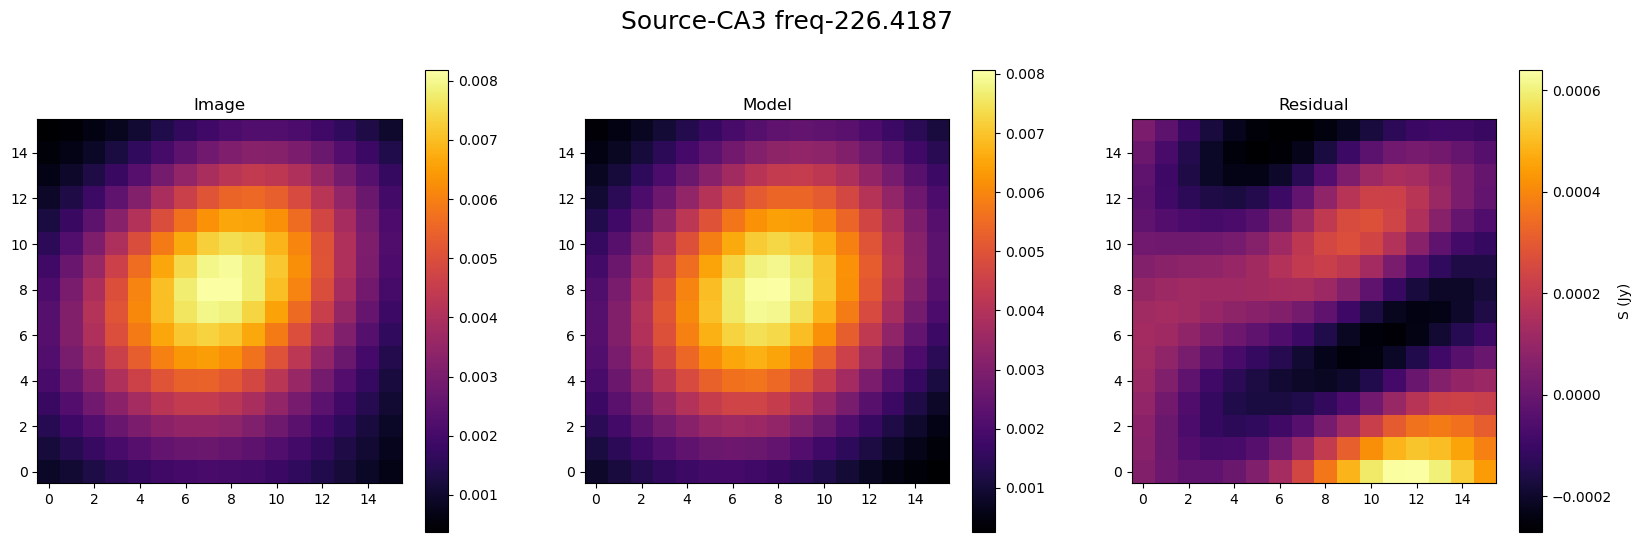

Parameter Error

Amplitude

8.098024842e-03 1.770364136e-04

x_mean

3.294575867e+03 1.028132516e-01

y_mean

3.579879019e+03 1.003013228e-01

x_stddev

4.115973080e+00 9.596429801e-02

y_stddev

5.148661666e+00 1.314115266e-01

theta

-7.116981823e+00 8.014986823e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.91991185, 14.51525451)>


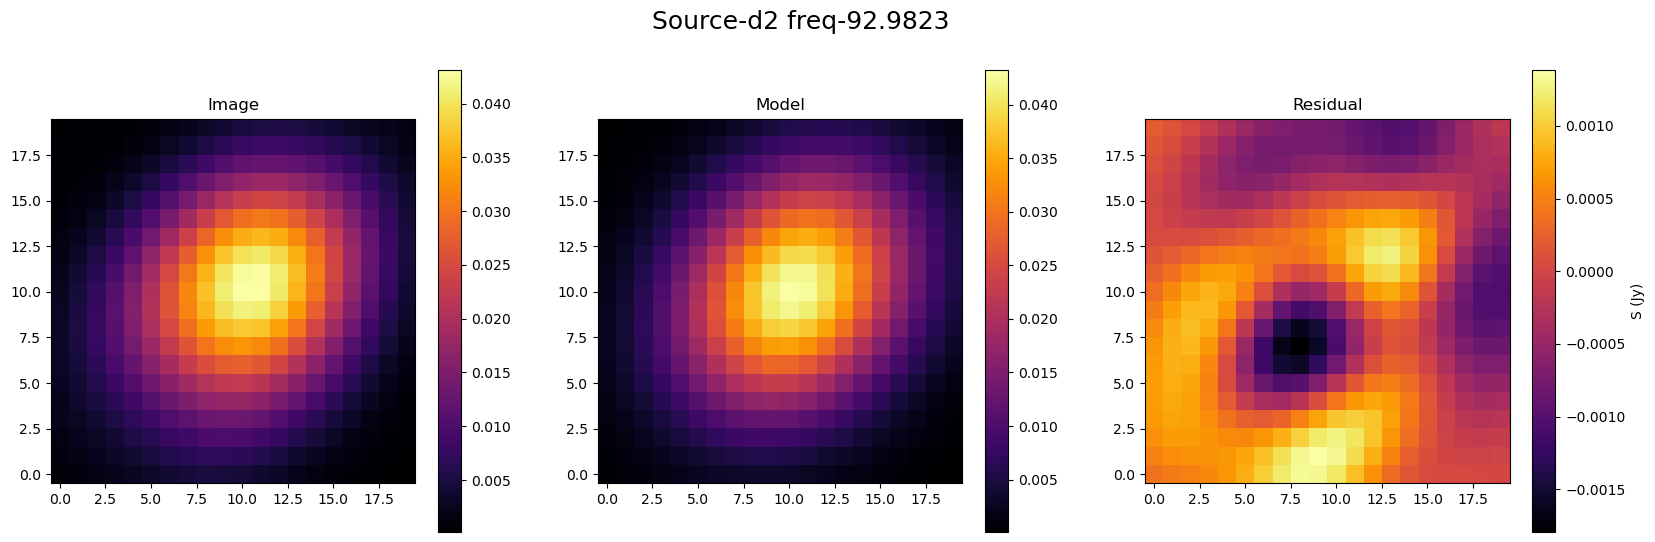

Parameter Error

Amplitude

4.334628767e-02 6.406366511e-04

x_mean

7.628300477e+03 6.352709685e-02

y_mean

7.226089485e+03 6.643789566e-02

x_stddev

3.935790551e+00 5.865414704e-02

y_stddev

4.867255856e+00 7.414817502e-02

theta

5.599936144e+00 5.03747949e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122782, 14.50395801)>


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


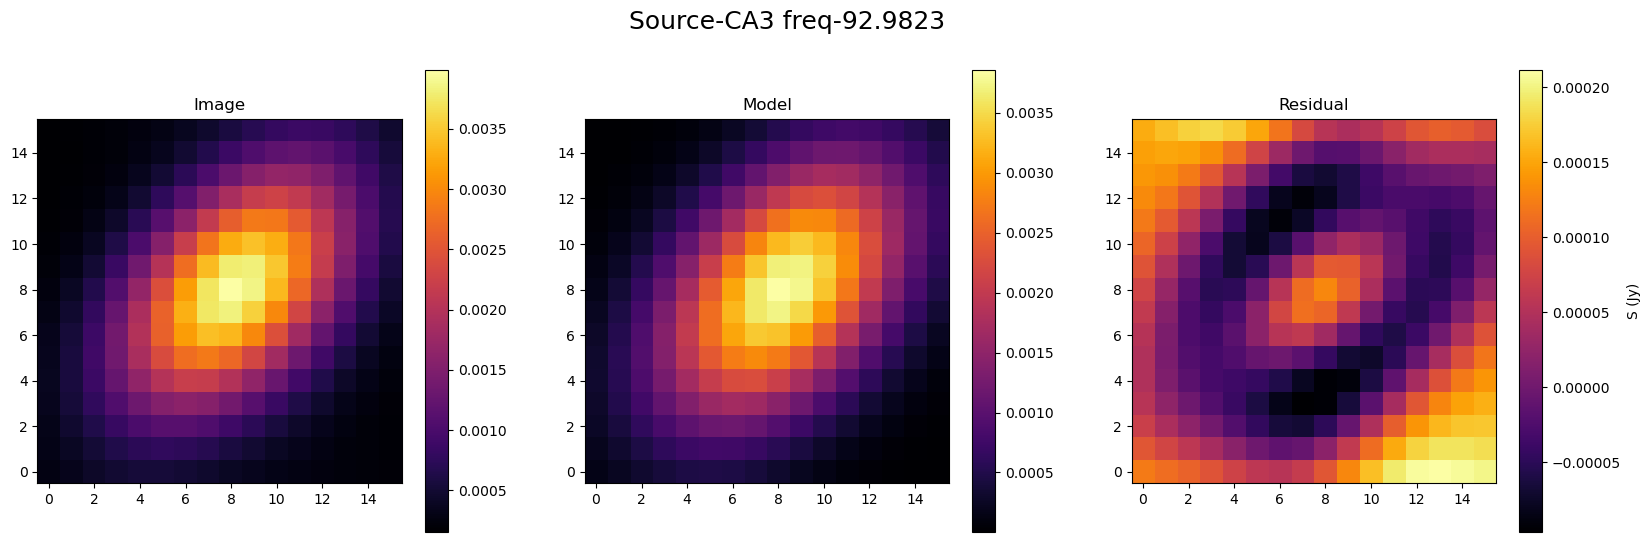

Parameter Error

Amplitude

3.864660335e-03 9.373147247e-05

x_mean

7.04720399e+03 8.854048944e-02

y_mean

7.342019719e+03 9.496941747e-02

x_stddev

4.557544129e+00 1.184819616e-01

y_stddev

2.853366386e+00 6.933071966e-02

theta

8.597357339e-01 3.700291007e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122777, 14.50395807)>


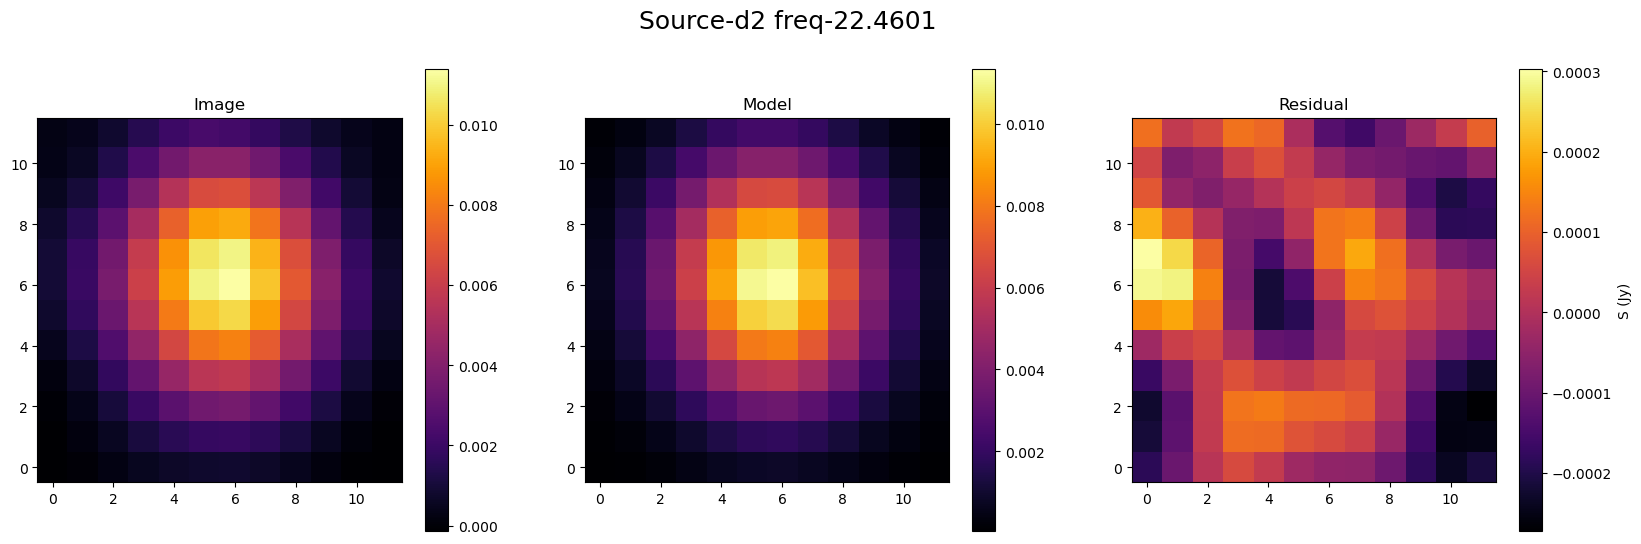

Parameter Error

Amplitude

1.151771352e-02 1.917987152e-04

x_mean

5.218615043e+03 3.887028644e-02

y_mean

4.959186077e+03 4.536435585e-02

x_stddev

2.35789366e+00 3.932334434e-02

y_stddev

2.722081357e+00 4.782805656e-02

theta

-9.35378897e+00 8.192741541e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836601, 14.4973424)>


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


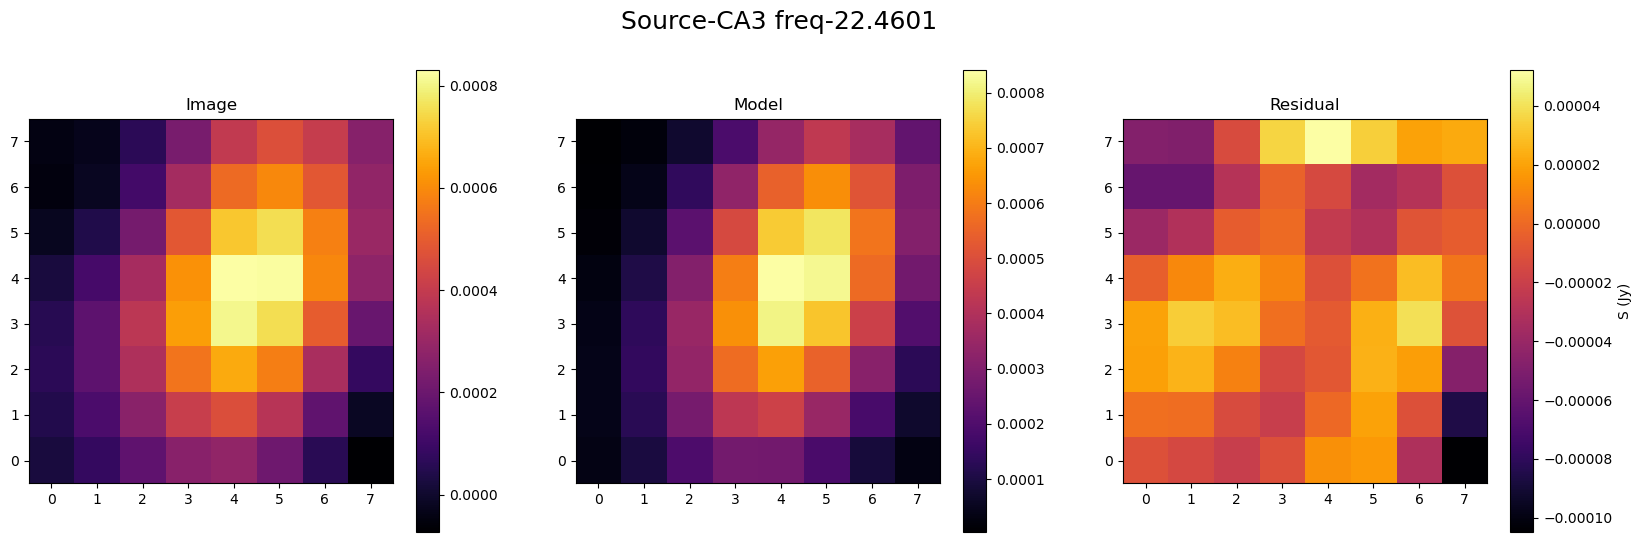

Parameter Error

Amplitude

8.69973245e-04 6.988139620e-05

x_mean

4.948413209e+03 1.426088778e-01

y_mean

5.014913612e+03 2.229965868e-01

x_stddev

2.738692985e+00 2.950405803e-01

y_stddev

1.609434402e+00 1.311656517e-01

theta

1.062651131e+01 1.128853044e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836557, 14.49734314)>


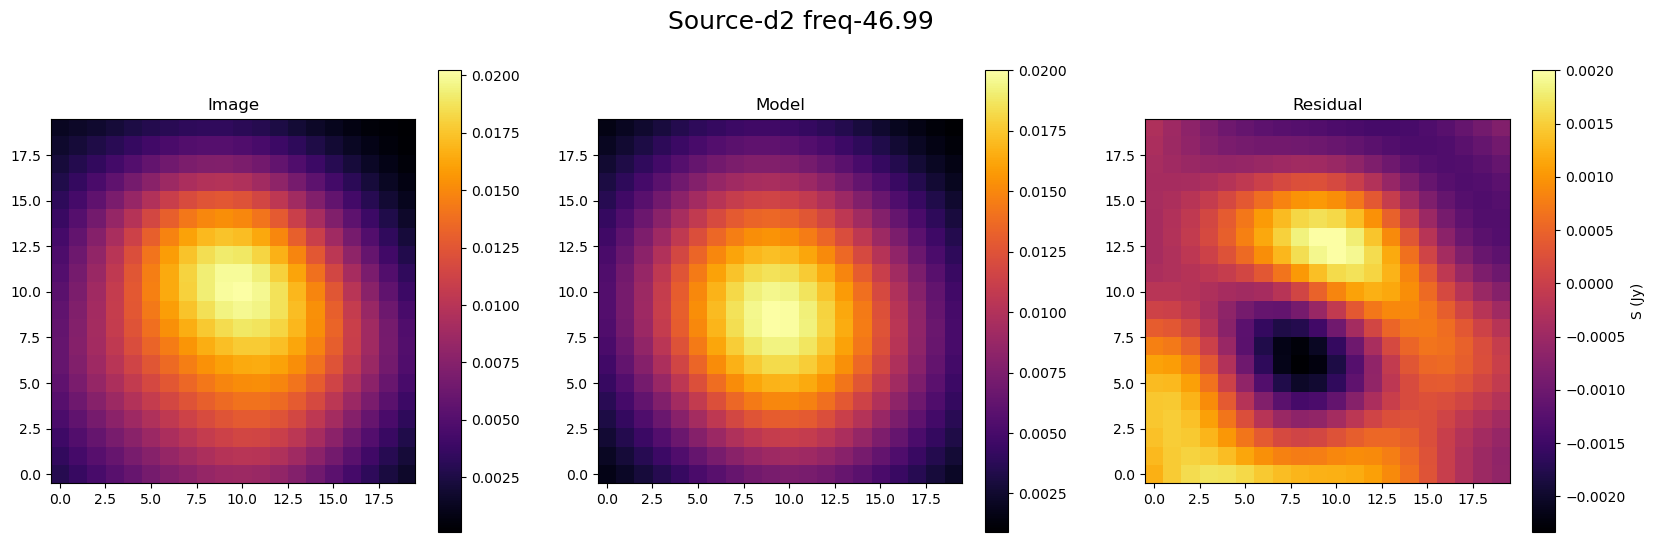

Parameter Error

Amplitude

2.008847220e-02 7.409843248e-04

x_mean

8.157326343e+03 2.127037009e-01

y_mean

7.379601716e+03 2.279344148e-01

x_stddev

5.666115271e+00 2.334458272e-01

y_stddev

6.235873557e+00 2.728590882e-01

theta

3.683851121e+00 3.190775139e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760973, 14.50775905)>


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


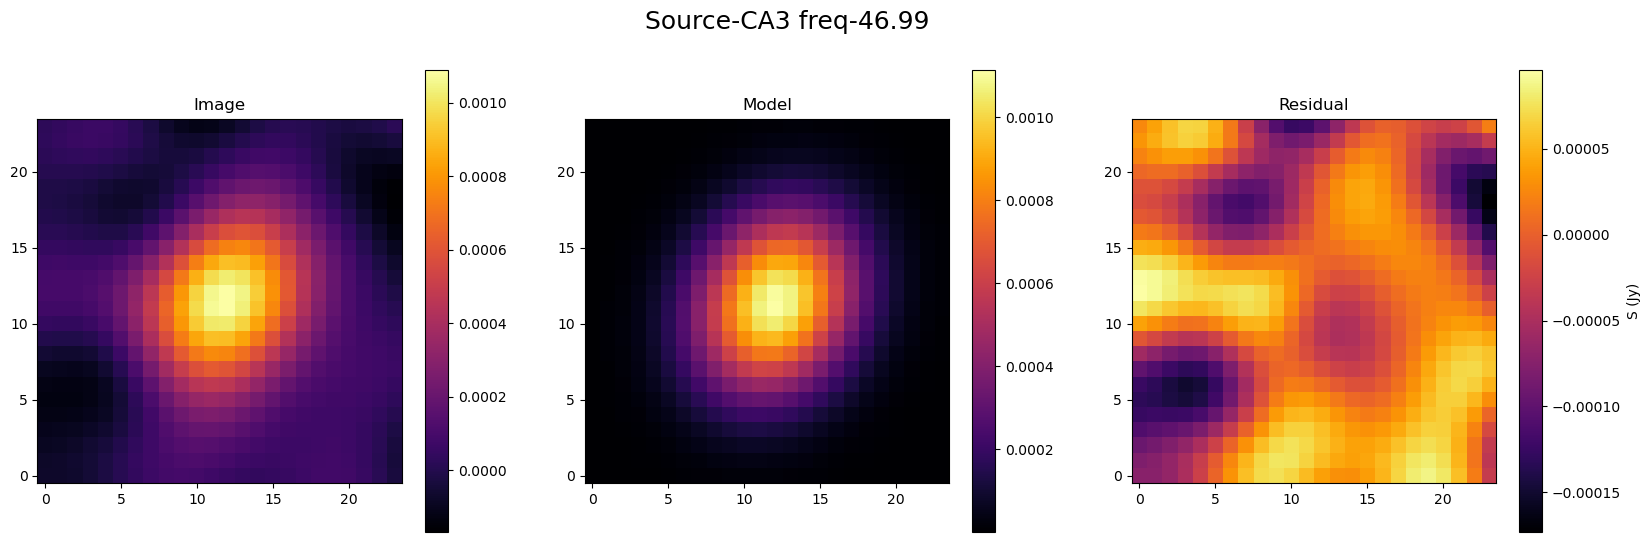

Parameter Error

Amplitude

1.118561057e-03 6.902485057e-05

x_mean

7.345059411e+03 2.223309533e-01

y_mean

7.543367160e+03 2.494930593e-01

x_stddev

4.194490305e+00 2.591225626e-01

y_stddev

3.429205715e+00 2.115685415e-01

theta

1.051719974e+01 2.152951863e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760972, 14.50775908)>


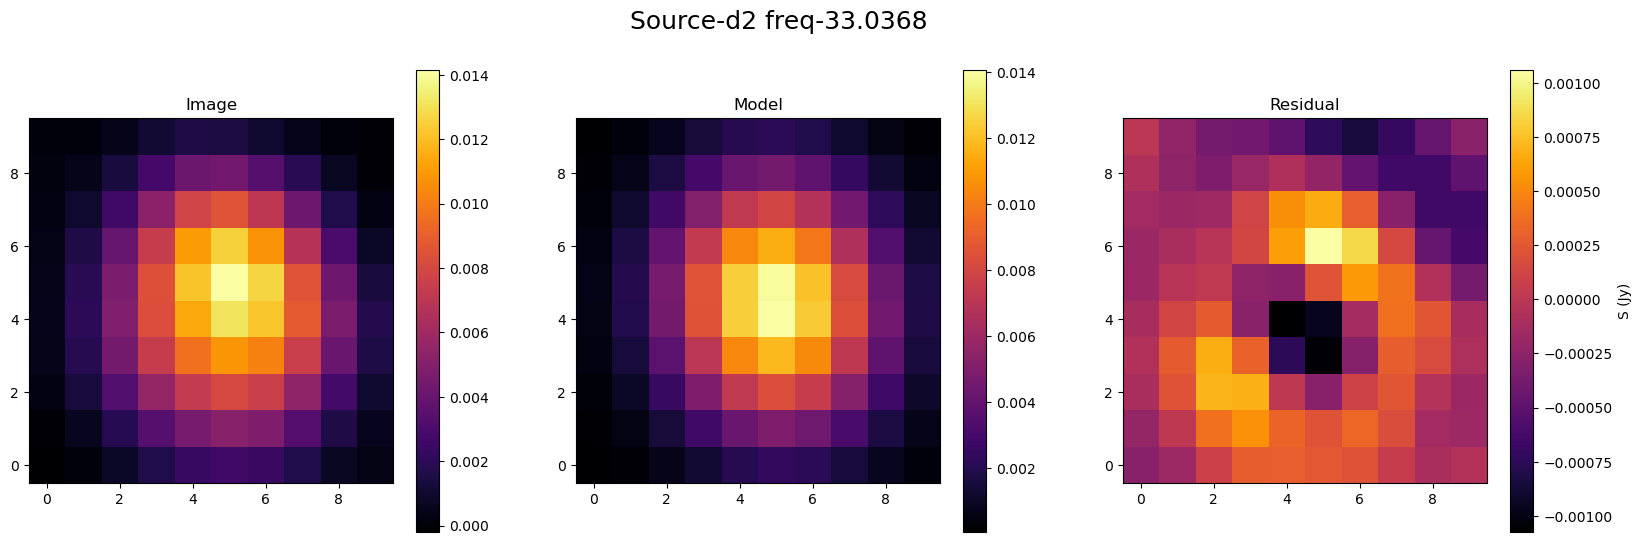

Parameter Error

Amplitude

1.431713693e-02 7.768683618e-04

x_mean

5.218963771e+03 1.069167482e-01

y_mean

4.959446872e+03 1.275303686e-01

x_stddev

2.362505537e+00 1.350391613e-01

y_stddev

1.985948994e+00 1.084625095e-01

theta

1.702578702e+00 2.204447499e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836638, 14.49734327)>


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


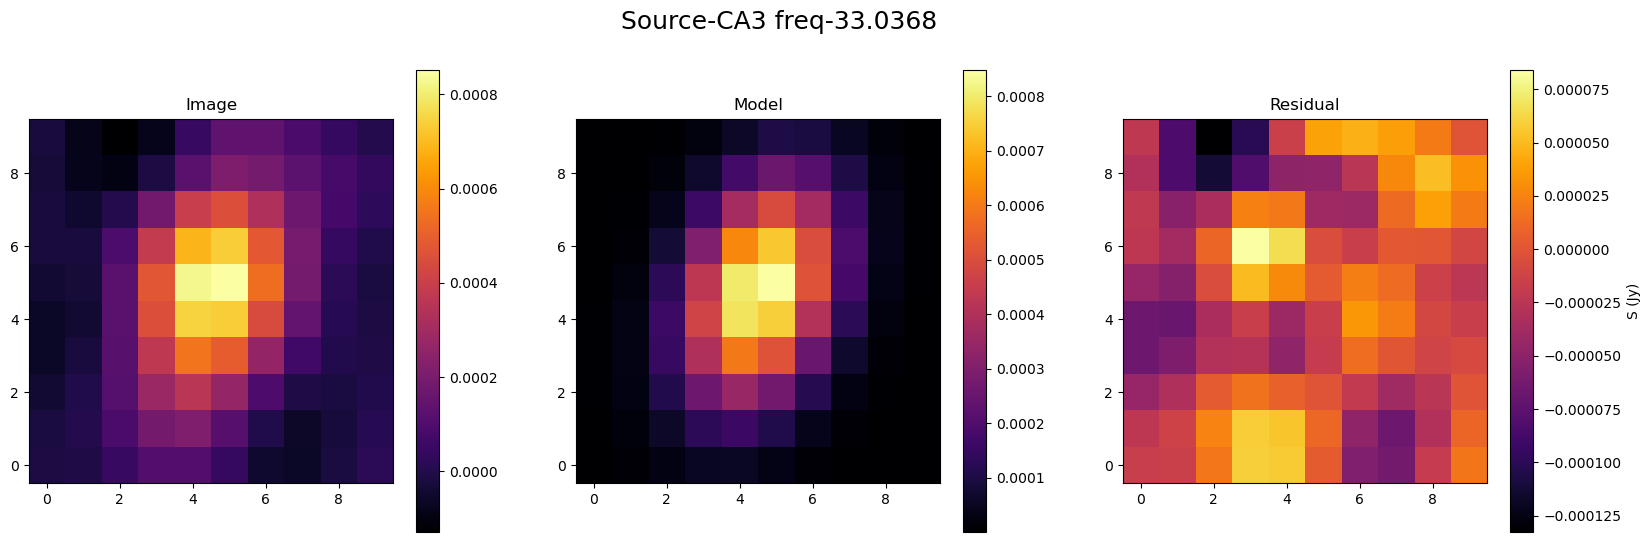

Parameter Error

Amplitude

8.911596611e-04 1.016595052e-04

x_mean

4.948565609e+03 1.580022952e-01

y_mean

5.014786831e+03 2.327257824e-01

x_stddev

2.104487219e+00 2.442272007e-01

y_stddev

1.293454856e+00 1.469801164e-01

theta

1.068304011e+01 1.594514852e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836616, 14.49734371)>


In [3]:
ca3_positions_1mm = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51n_cont_briggsSC_tclean.image.fits'

ca3_positions_1mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_1mm,
                                          amplitude=1, x=4654, y=3311, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=6, freq='226.4187', source_name='d2')

ca3_positions_1mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_1mm,
                                          amplitude=1, x=3295, y=3580, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=8, freq='226.4187', source_name='CA3')

ca3_positions_3mm = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
# directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'

# d2
ca3_positions_3mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_3mm,
                                          amplitude=5e-2, x=7628, y=7226, x_stddev=12, y_stddev=12, theta=11*np.pi/6, 
                                          size=10, freq='92.9823', source_name='d2')

# CA3
ca3_positions_3mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_3mm,
                                          amplitude=1, x=7047, y=7342, x_stddev=9, y_stddev=9, theta=np.pi/4, 
                                          size=8, freq='92.9823', source_name='CA3')

ca3_positions_Kband = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'
# directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'

# d2
ca3_positions_Kband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kband,
                                          amplitude=1, x=5219, y=4959, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=6, freq='22.4601', source_name='d2')

# CA3
ca3_positions_Kband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kband,
                                          amplitude=1, x=4948, y=5015, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=4, freq='22.4601', source_name='CA3')


ca3_positions_Qband = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'

ca3_positions_Qband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Qband,
                                          amplitude=1, x=8158, y=7381, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=10, freq='46.99', source_name='d2')

ca3_positions_Qband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Qband,
                                          amplitude=1, x=7345, y=7544, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99', source_name='CA3')

ca3_positions_Kaband = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'

ca3_positions_Kaband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kaband,
                                          amplitude=1, x=5219, y=4960, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=5, freq='33.0368', source_name='d2')

ca3_positions_Kaband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kaband,
                                          amplitude=1, x=4949, y=5015, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=5, freq='33.0368', source_name='CA3')

In [4]:
tables = [
    ca3_positions_1mm,
    ca3_positions_3mm,
    ca3_positions_Kband,
    ca3_positions_Qband,
    ca3_positions_Kaband,
]

ca3_all_d2 = pd.concat(
    [t[t["source"] == "d2"] for t in tables],   # list-comprehension of filtered dfs
    ignore_index=True                           # re-index from 0,1,2,…
)
ca3_all_d2['freq'] = ca3_all_d2['freq'].astype(float)
ca3_all_d2 = ca3_all_d2.sort_values(by='freq', ascending=False)



ca3_all_CA3 = pd.concat(
    [t[t["source"] == "CA3"] for t in tables],   # list-comprehension of filtered dfs
    ignore_index=True                           # re-index from 0,1,2,…
)
ca3_all_CA3['freq'] = ca3_all_CA3['freq'].astype(float)
ca3_all_CA3 = ca3_all_CA3.sort_values(by='freq', ascending=False)

In [5]:
ca3_all_CA3

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,ra_hms_error,dec_dms_error
0,CA3,226.4187,3295,3580,8.098024842e-03,1.770364136e-04,3.294575867e+03,1.028132516e-01,3.579879019e+03,1.003013228e-01,...,290.919912,14.518238,14.515255,19:23:40.0982,14:31:05.6556,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,19:23:40.77884,14:30:54.91623
1,CA3,92.9823,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,...,290.931228,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,19:23:43.49467,14:30:14.24905
3,CA3,46.9900,7345,7544,1.118561057e-03,6.902485057e-05,7.345059411e+03,2.223309533e-01,7.543367160e+03,2.494930593e-01,...,290.927610,14.518236,14.507759,19:23:40.0974,14:31:05.6491,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,19:23:42.62633,14:30:27.93270
4,CA3,33.0368,4949,5015,8.911596611e-04,1.016595052e-04,4.948565609e+03,1.580022952e-01,5.014786831e+03,2.327257824e-01,...,290.938366,14.518239,14.497344,19:23:40.0967,14:31:05.6591,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,19:23:45.20788,14:29:50.43737
2,CA3,22.4601,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,...,290.938366,14.518239,14.497343,19:23:40.0967,14:31:05.6591,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,19:23:45.20774,14:29:50.43532


In [43]:
ca3_all_d2['amplitude'].astype(float) * 1000

0    23.301455
1    43.346288
3    20.088472
4    14.317137
2    11.517714
Name: amplitude, dtype: float64

In [41]:
ca3_all_d2['amplitude_error'].astype(float) * 1000

0    0.287817
1    0.640637
3    0.740984
4    0.776868
2    0.191799
Name: amplitude_error, dtype: float64

In [24]:
ca3_all_CA3

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header
0,CA3,226.4187,3295,3580,8.098024842e-03,1.770364136e-04,3.294575867e+03,1.028132516e-01,3.579879019e+03,1.003013228e-01,290.917076,290.919912,14.518238,14.515255,19:23:40.0982,14:31:05.6556,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...
1,CA3,92.9823,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,290.917074,290.931228,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...
3,CA3,46.9900,7345,7544,1.118561057e-03,6.902485057e-05,7.345059411e+03,2.223309533e-01,7.543367160e+03,2.494930593e-01,290.917073,290.927610,14.518236,14.507759,19:23:40.0974,14:31:05.6491,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
4,CA3,33.0368,4949,5015,8.911596611e-04,1.016595052e-04,4.948565609e+03,1.580022952e-01,5.014786831e+03,2.327257824e-01,290.917070,290.938366,14.518239,14.497344,19:23:40.0967,14:31:05.6591,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...
2,CA3,22.4601,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,290.917070,290.938366,14.518239,14.497343,19:23:40.0967,14:31:05.6591,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...


In [6]:
ca3_all_CA3['freq'].astype(float)

2     22.4601
4     33.0368
3     46.9900
1     92.9823
0    226.4187
Name: freq, dtype: float64

In [7]:
freq_CA3 = ca3_all_CA3['freq'].astype(float)*u.GHz
amp_CA3 = ca3_all_CA3['amplitude'].astype(float)*1000*u.mJy
amp_error_CA3 = ca3_all_CA3['amplitude_error'].astype(float)*1000*u.mJy

freq_d2 = ca3_all_d2['freq'].astype(float)*u.GHz
amp_d2 = ca3_all_d2['amplitude'].astype(float)*1000*u.mJy
amp_error_d2 = ca3_all_d2['amplitude_error'].astype(float)*1000*u.mJy

In [8]:
freq_CA3

2     22.4601
4     33.0368
3     46.9900
1     92.9823
0    226.4187
Name: freq, dtype: float64

# CA3

In [9]:
data = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/W51CA3_Fitting/hiimodel/hiiregion_W51_CA3_pbcor_03-with_Updated_band6.csv')

In [10]:
data['mu_GHz']

0    226.00
1     86.00
2     46.99
3     33.04
Name: mu_GHz, dtype: float64

INFO: Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000 [HII_model]


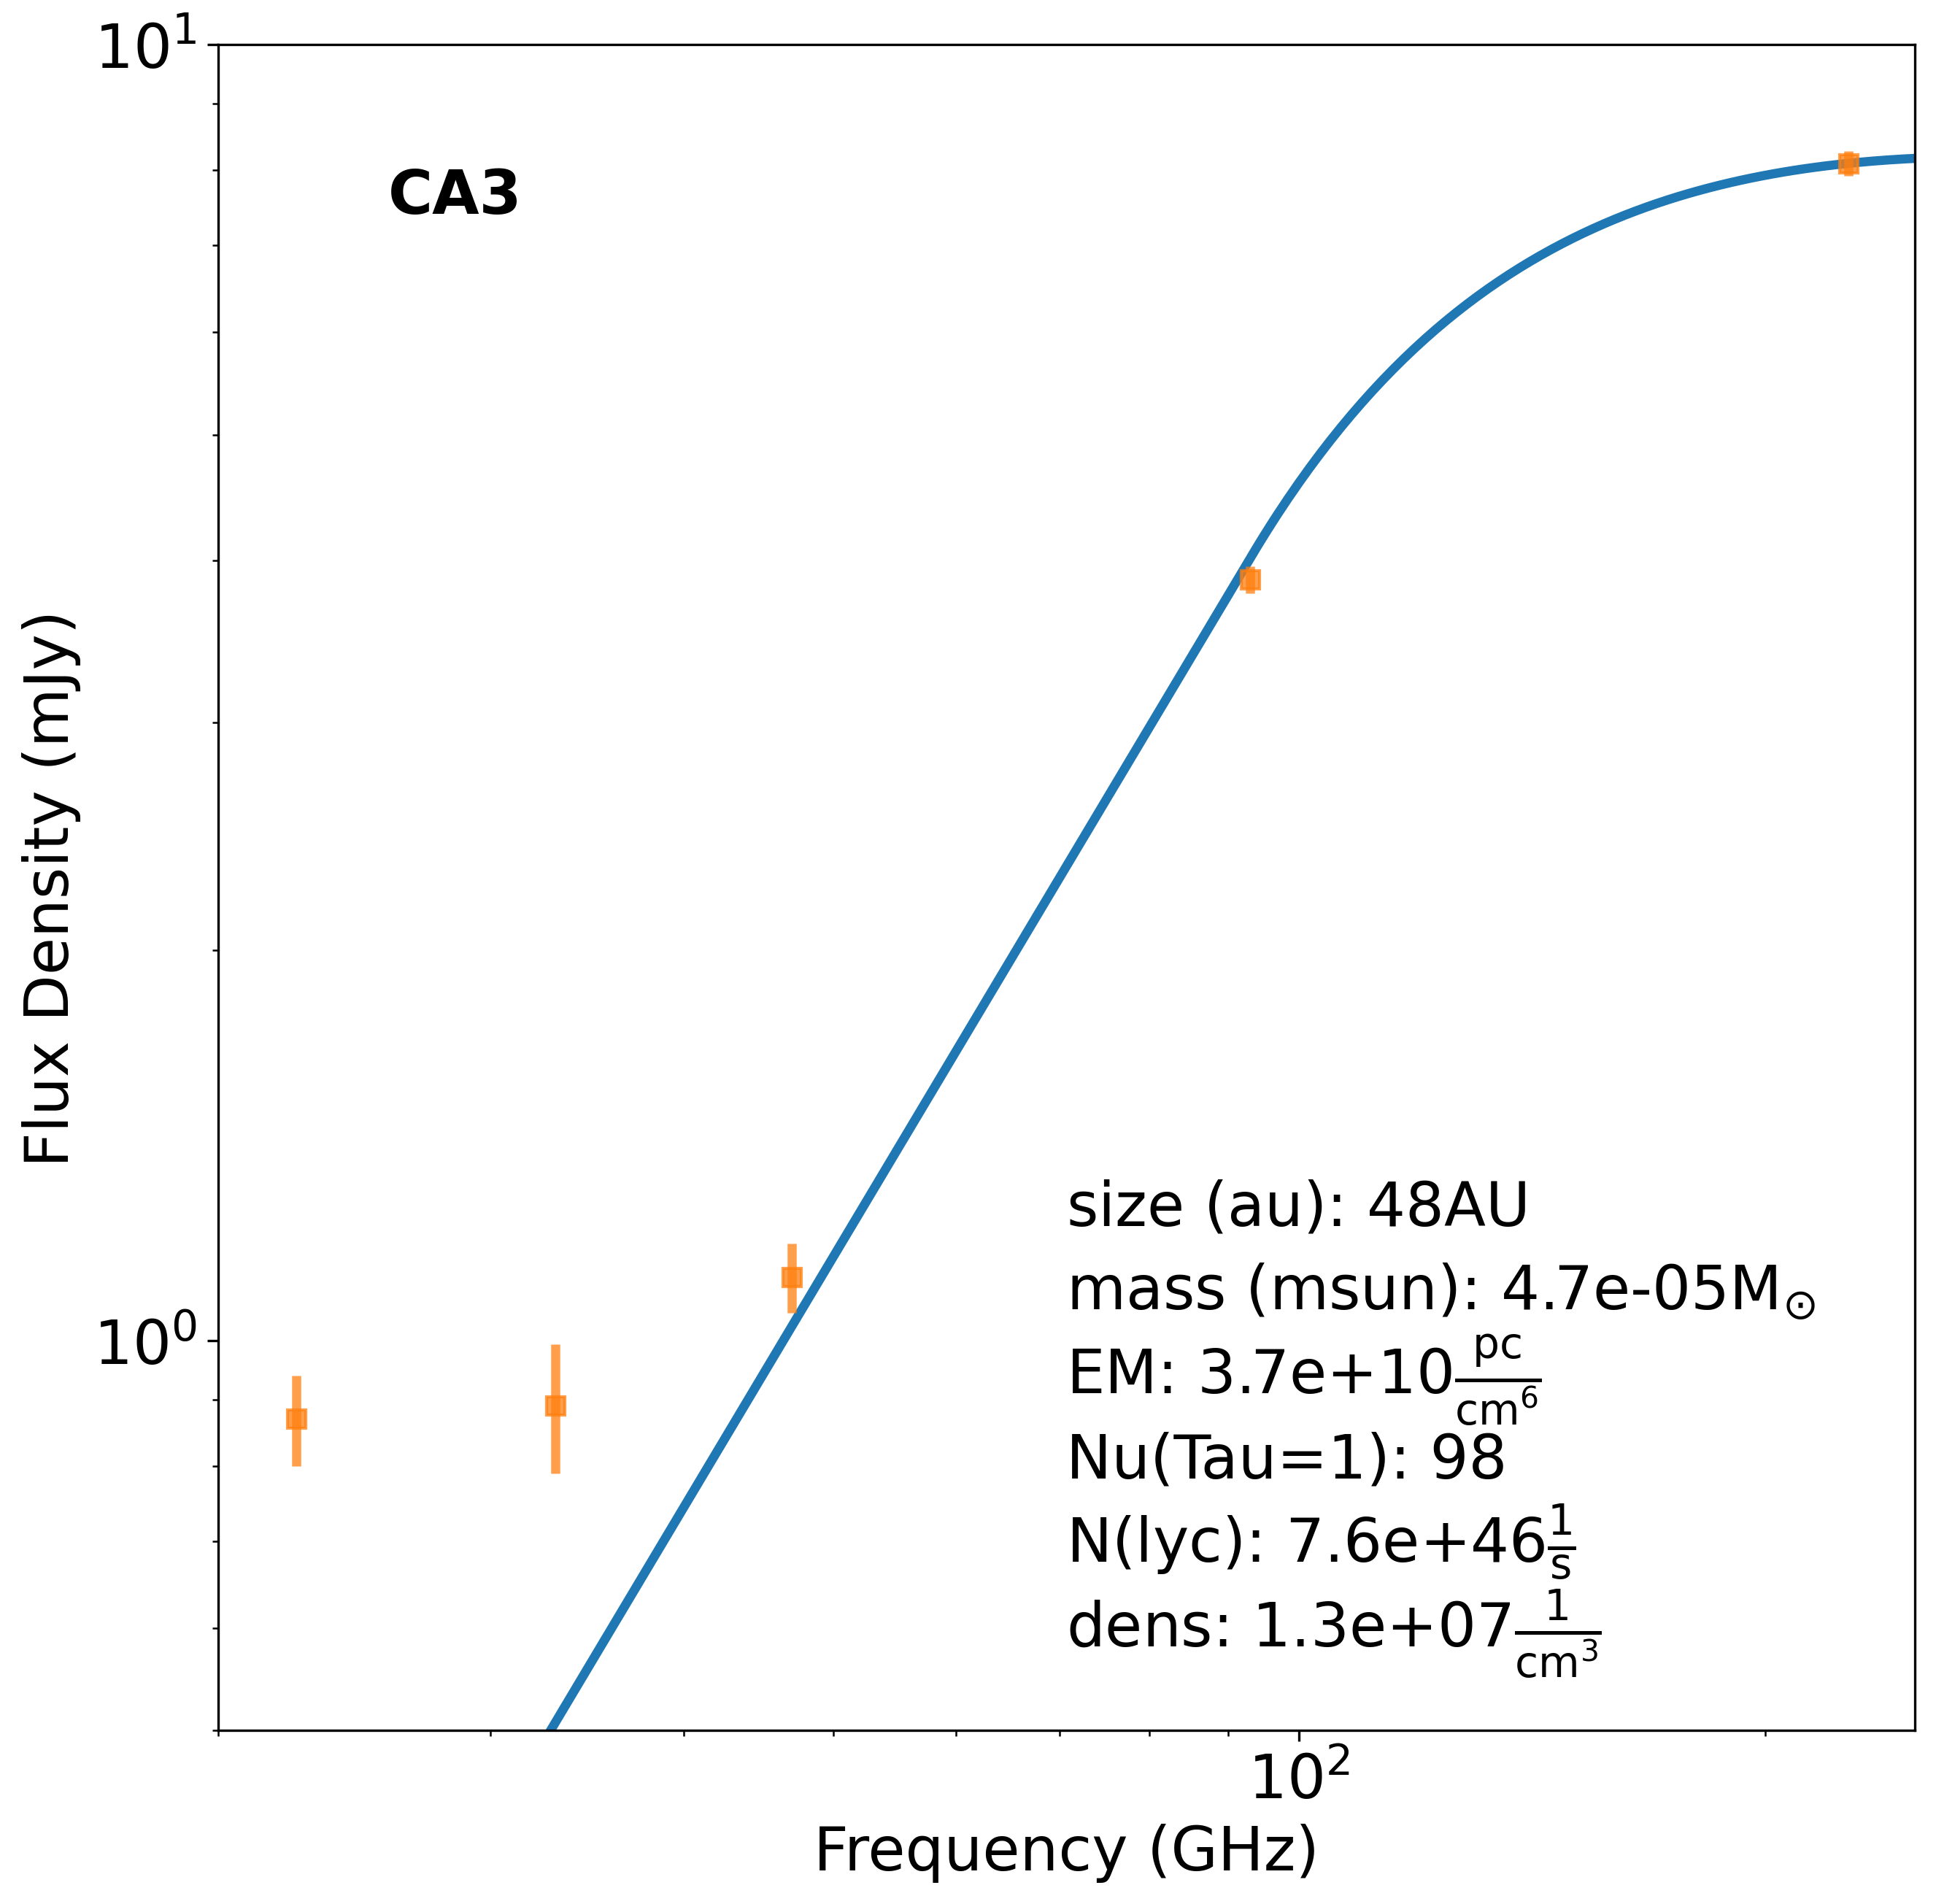

In [20]:
fig , ax = plt.subplots(figsize=(10,10), dpi=300)

ca3 = HIIregion(freq_CA3, 
                amp_CA3, 
                fluxerr=amp_error_CA3,
                dist_kpc=5.1*u.kpc, EMguess=1e10)
ca3.loglogplot(numin=5*u.GHz, numax=250*u.GHz, annotation_xpos=0.5)
ax.text(0.1,.9,"CA3",fontsize = 20, weight='bold',transform=ax.transAxes)

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 50

plt.xlim(20,250)
plt.ylim(0.5, 10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel(xlabel='Frequency (GHz)',fontsize=20)
plt.ylabel(ylabel='Flux Density (mJy)',fontsize=20)
fig.savefig(fname='CA3_HII_region_fit.png', transparent=False)

# d2

In [12]:
data = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/W51CA3_Fitting/hiimodel/sed_d2_pbcor.csv')

INFO: Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000 [HII_model]


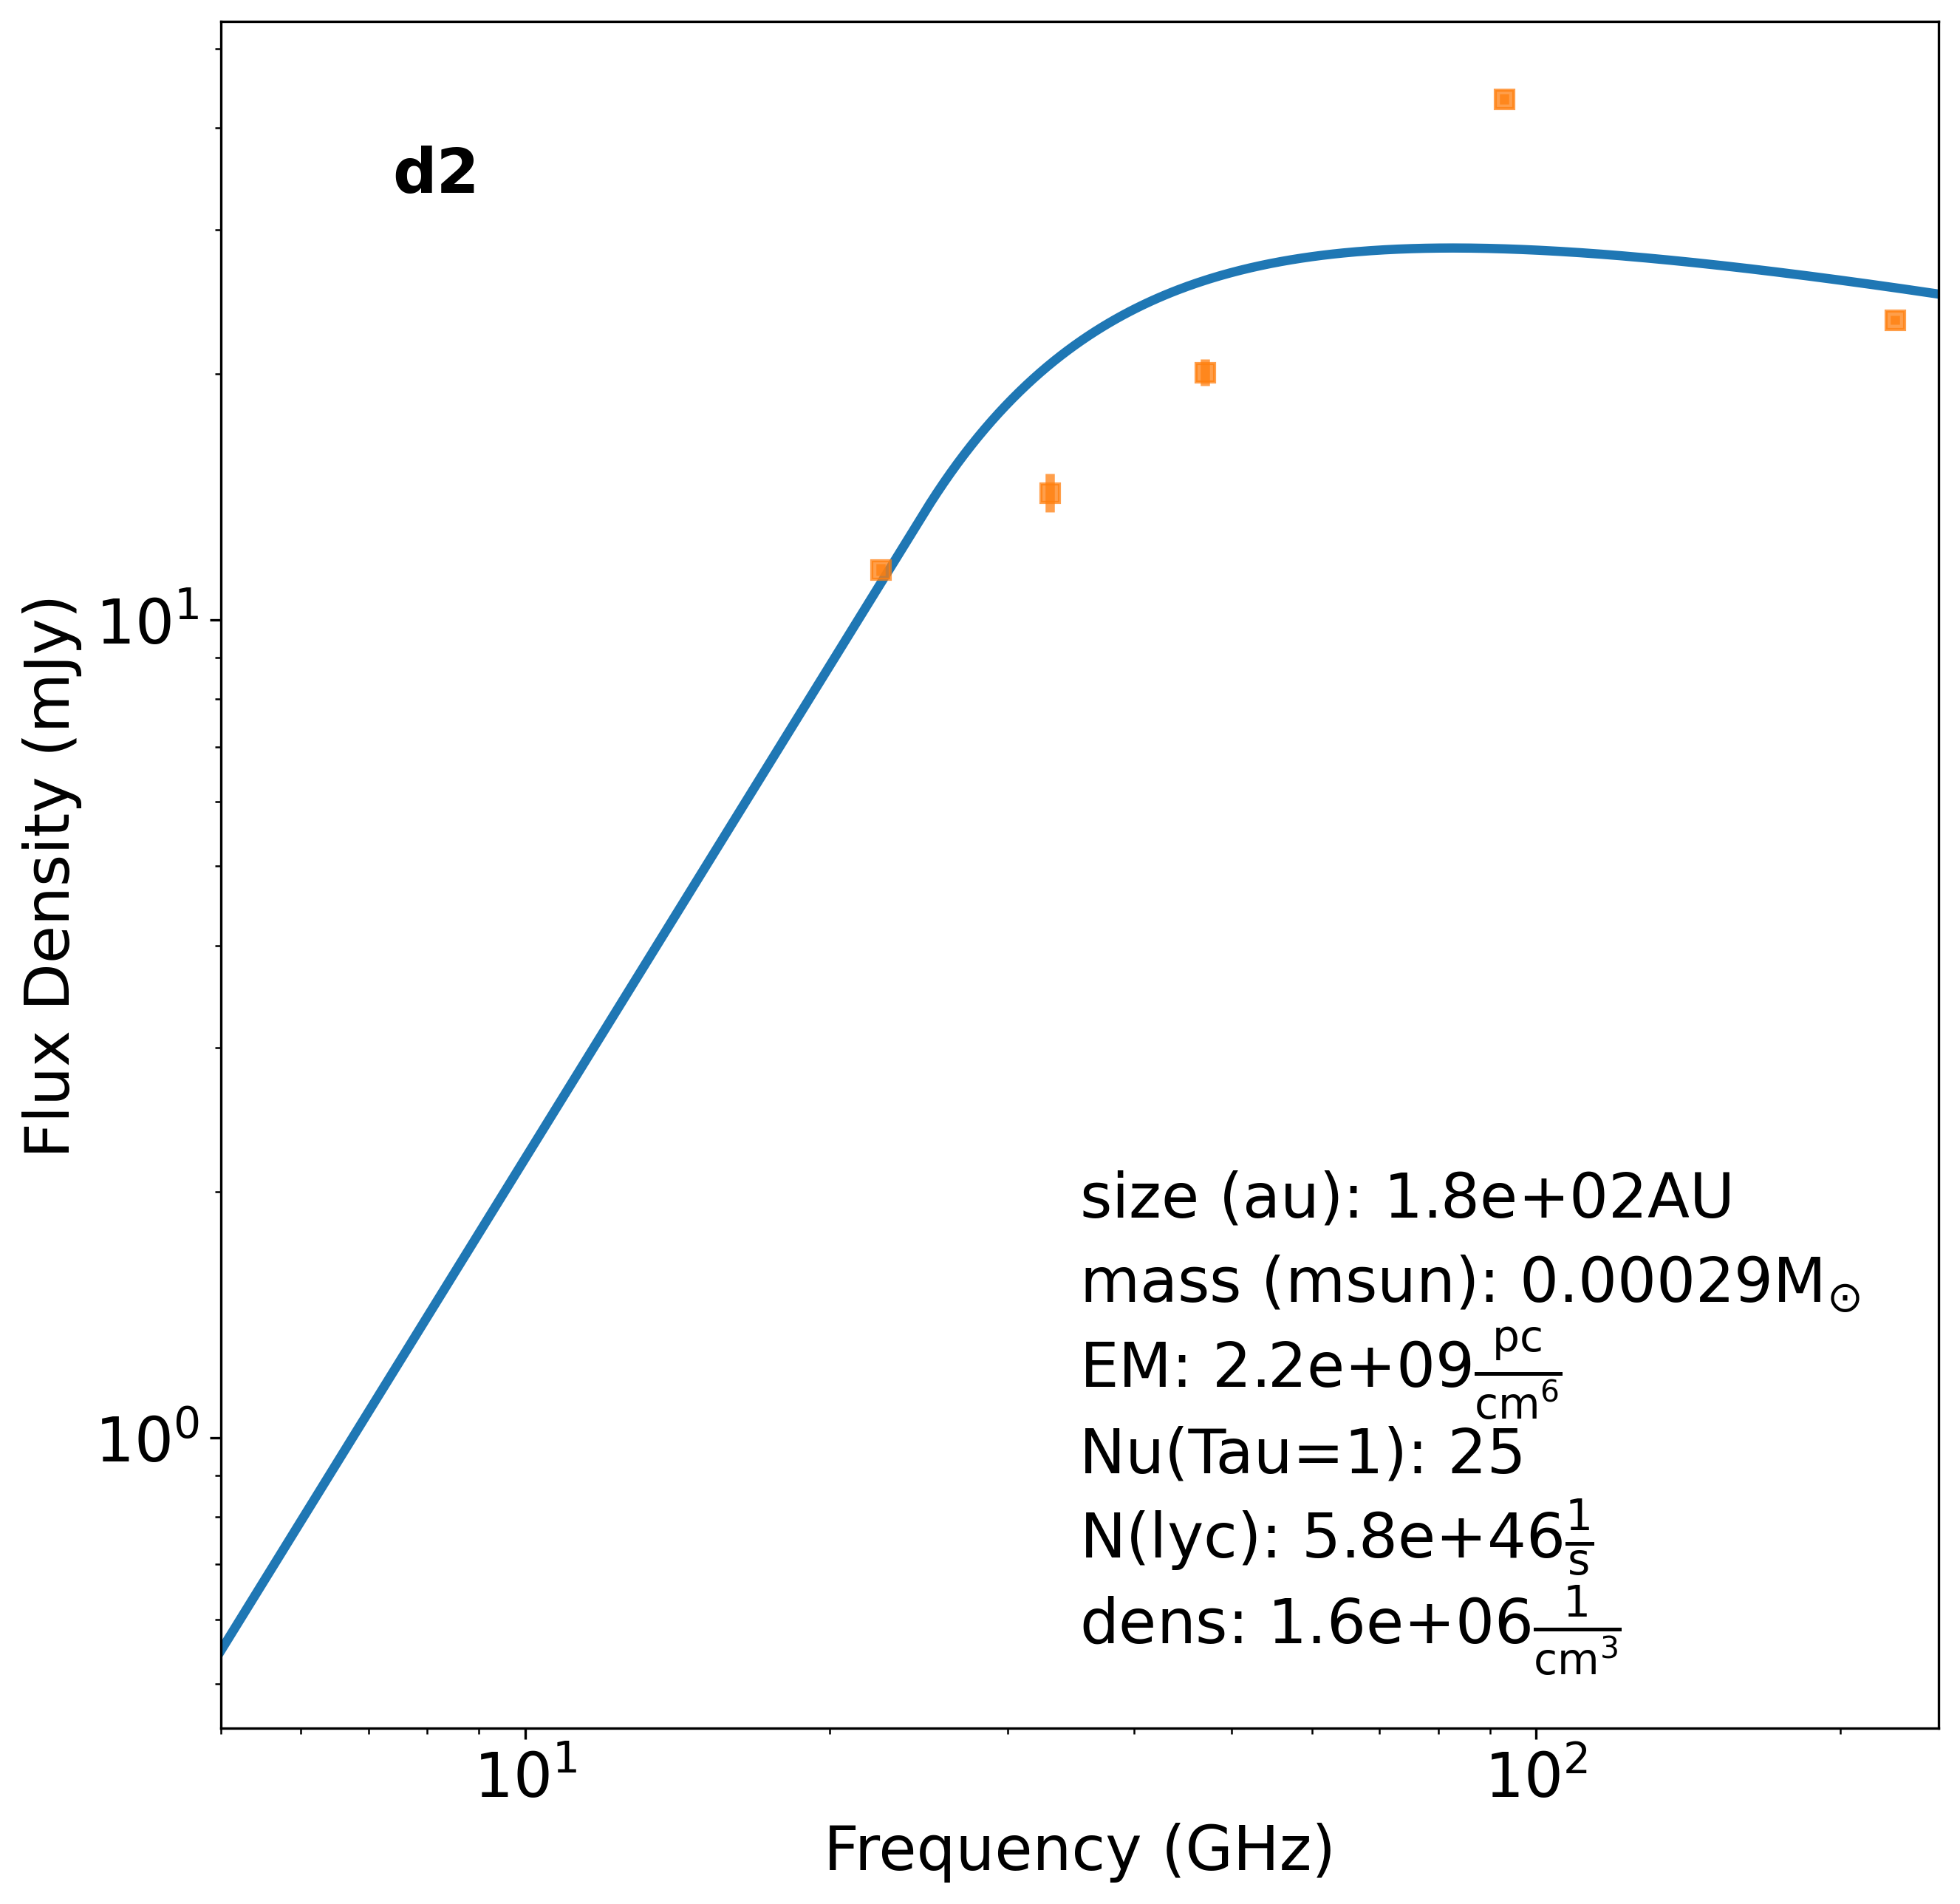

In [21]:
fig , ax = plt.subplots(figsize=(10,10), dpi=300)

# ca3 = HIIregion(data['mu_GHz']*u.GHz, data['amp_Jy']*1000*u.mJy, fluxerr=data['amp_Jy_error']*1000*u.mJy,
#                 dist_kpc=5.1*u.kpc, EMguess=1e10)

d2 = HIIregion(freq_d2, 
                amp_d2, 
                fluxerr=amp_error_d2,
                dist_kpc=5.1*u.kpc, EMguess=1e10)

d2.loglogplot(numin=5*u.GHz, numax=250*u.GHz, annotation_xpos=0.5)
ax.text(0.1,.9,"d2",fontsize = 20, weight='bold',transform=ax.transAxes)

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 50
plt.xlim(5,250)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel(xlabel='Frequency (GHz)',fontsize=20)
plt.ylabel(ylabel='Flux Density (mJy)',fontsize=20)
fig.savefig(fname='d2_HII_region_fit.png', transparent=False)